In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load data
inventory = pd.read_csv("../data/inventory_optimization.csv")
item_value = pd.read_csv("../data/item_value_analysis.csv")

print("Data loaded successfully!")
print("Inventory:", inventory.shape)
print("Item Value:", item_value.shape)

Data loaded successfully!
Inventory: (30490, 11)
Item Value: (30490, 9)


In [2]:
# ABC Analysis - Classify items by value contribution
# A = Top 20% items (high value), B = Next 30%, C = Remaining 50%

merged = inventory.merge(
    item_value[['item_id', 'store_id', 'projected_annual_value', 'value_segment']],
    on=['item_id', 'store_id'], how='left'
)

merged = merged.sort_values('projected_annual_value', ascending=False).reset_index(drop=True)
merged['cumulative_pct'] = (merged.index + 1) / len(merged) * 100

def abc_classify(pct):
    if pct <= 20:
        return 'A'
    elif pct <= 50:
        return 'B'
    else:
        return 'C'

merged['abc_class'] = merged['cumulative_pct'].apply(abc_classify)

print("ABC Classification Complete!")
print("\nABC Distribution:")
print(merged['abc_class'].value_counts())

print("\nValue Contribution by Class:")
print(merged.groupby('abc_class')['projected_annual_value'].sum().round(2))

ABC Classification Complete!

ABC Distribution:
abc_class
C    15245
B     9147
A     6098
Name: count, dtype: int64

Value Contribution by Class:
abc_class
A    23823874.80
B     8799255.47
C     3408251.36
Name: projected_annual_value, dtype: float64


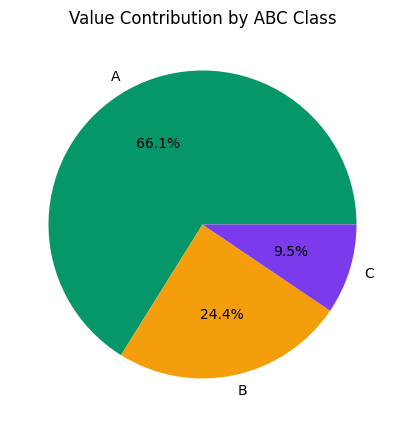

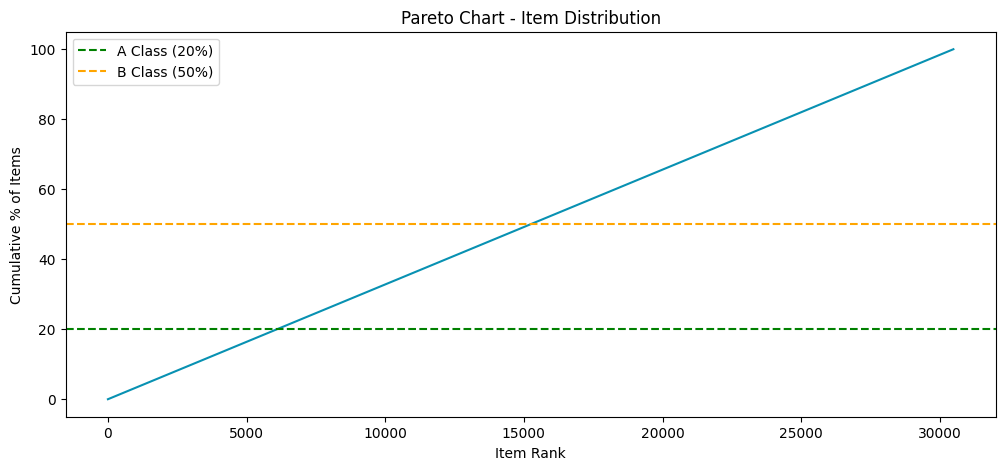

Recommended Strategy:
A Class: Tight inventory control, frequent monitoring
B Class: Moderate control, periodic review
C Class: Simple control, bulk ordering


In [3]:
# Visualize ABC Analysis
plt.figure(figsize=(10,5))
abc_summary = merged.groupby('abc_class')['projected_annual_value'].sum()
colors = ['#059669', '#F59E0B', '#7C3AED']
plt.pie(abc_summary.values, labels=abc_summary.index,
        autopct='%1.1f%%', colors=colors)
plt.title("Value Contribution by ABC Class")
plt.show()

# Pareto chart
plt.figure(figsize=(12,5))
plt.plot(merged.index, merged['cumulative_pct'], color='#0891B2')
plt.axhline(y=20, color='green', linestyle='--', label='A Class (20%)')
plt.axhline(y=50, color='orange', linestyle='--', label='B Class (50%)')
plt.title("Pareto Chart - Item Distribution")
plt.xlabel("Item Rank")
plt.ylabel("Cumulative % of Items")
plt.legend()
plt.show()

print("Recommended Strategy:")
print("A Class: Tight inventory control, frequent monitoring")
print("B Class: Moderate control, periodic review")
print("C Class: Simple control, bulk ordering")

Top 10 High Stockout Risk Items:
           item_id store_id abc_class  avg_daily_demand  safety_stock  \
23041  FOODS_3_008     WI_1         C          2.789271           1.0   
19130  FOODS_3_008     CA_2         C          2.658514           1.0   
27630  FOODS_2_128     CA_2         C          2.640579           1.0   
27684  FOODS_2_021     CA_2         C          2.451781           1.0   
25873  FOODS_3_589     TX_1         C          1.102856           0.0   
26505  FOODS_2_277     TX_1         C          1.080478           0.0   
1205   FOODS_3_228     CA_3         A          8.482525           7.0   
30322  FOODS_2_277     WI_1         C          1.056473           0.0   
21994  FOODS_3_008     WI_2         C          3.141153           2.0   
27300  FOODS_3_166     WI_1         C          1.045097           0.0   

       stockout_risk_score  
23041                 1.39  
19130                 1.33  
27630                 1.32  
27684                 1.23  
25873             

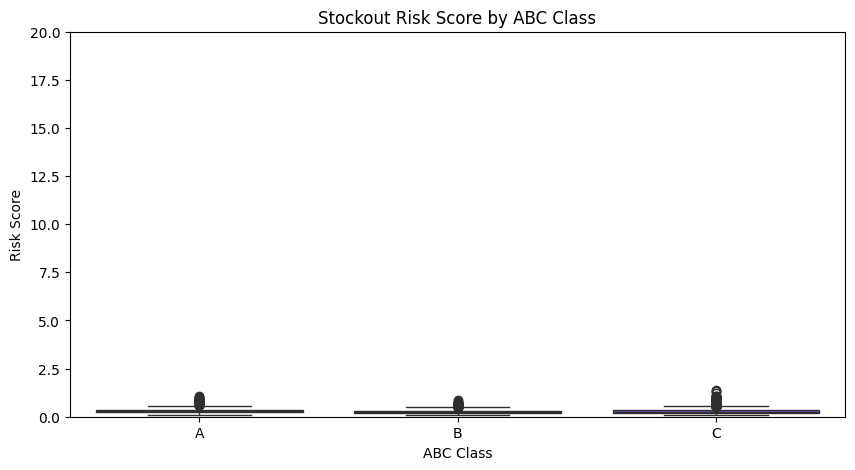


Average Risk Score by Class:
abc_class
A    0.31
B    0.26
C    0.28
Name: stockout_risk_score, dtype: float64


In [4]:
# Stockout Risk Analysis
# Items with high demand but low safety stock = high risk

merged['stockout_risk_score'] = (
    merged['avg_daily_demand'] / (merged['safety_stock'] + 1)
).round(2)

high_risk = merged.nlargest(10, 'stockout_risk_score')

print("Top 10 High Stockout Risk Items:")
print(high_risk[['item_id', 'store_id', 'abc_class', 
                  'avg_daily_demand', 'safety_stock', 'stockout_risk_score']])

# Risk by ABC class
plt.figure(figsize=(10,5))
sns.boxplot(x='abc_class', y='stockout_risk_score', data=merged,
            palette=['#059669', '#F59E0B', '#7C3AED'])
plt.title("Stockout Risk Score by ABC Class")
plt.xlabel("ABC Class")
plt.ylabel("Risk Score")
plt.ylim(0, 20)
plt.show()

print("\nAverage Risk Score by Class:")
print(merged.groupby('abc_class')['stockout_risk_score'].mean().round(2))

In [ ]:
# Save ABC analysis results
merged.to_csv("../data/abc_inventory_analysis.csv", index=False)

print("ABC analysis saved!")

print("\n" + "="*50)
print("WEEK 3 DAY 2 SUMMARY")
print("="*50)
print("ABC Classification Complete")
print("\nA Class: 6,098 items - $23.8M value (highest priority)")
print("B Class: 9,147 items - $8.8M value (medium priority)")
print("C Class: 15,245 items - $3.4M value (lowest priority)")
print("\nStockout Risk Analysis:")
print("A Class Risk: 0.31")
print("B Class Risk: 0.26")
print("C Class Risk: 0.28")
print("\nAll classes show low and balanced risk!")
print("="*50)